In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve().parents[0]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from export.report_exports import (
    create_report_output_dirs,
    export_report_table,
    save_report_figure,
    set_report_plot_style,
)

NOTEBOOK_NAME = "09_final_model_comparison_and_results_tables"

report_dirs = create_report_output_dirs(
    project_root=PROJECT_ROOT,
    notebook_name=NOTEBOOK_NAME,
)

OUTPUT_DIR = report_dirs.output_dir
FIGURE_DIR = report_dirs.figure_dir
TABLE_DIR = report_dirs.table_dir

OUTPUT_07_TABLE_DIR = (
        PROJECT_ROOT
        / "Outputs"
        / "07_stress_scenario_analysis"
        / "Tables"
)

OUTPUT_08_TABLE_DIR = (
        PROJECT_ROOT
        / "Outputs"
        / "08_tail_risk_portfolio_metrics"
        / "Tables"
)

pd.set_option("display.max_columns", 250)
pd.set_option("display.float_format", "{:,.4f}".format)

sns.set_theme(style="whitegrid")
set_report_plot_style()

print("Project root:", PROJECT_ROOT)
print("Notebook 07 table directory:", OUTPUT_07_TABLE_DIR)
print("Notebook 08 table directory:", OUTPUT_08_TABLE_DIR)
print("Notebook 09 output directory:", OUTPUT_DIR)

Project root: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance
Notebook 07 table directory: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\07_stress_scenario_analysis\Tables
Notebook 08 table directory: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\08_tail_risk_portfolio_metrics\Tables
Notebook 09 output directory: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\09_final_model_comparison_and_results_tables


In [2]:
def read_required_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(
            f"Required file not found: {path}\n"
            "Run notebooks 07 and 08 first, then rerun this notebook."
        )

    return pd.read_csv(path)


def read_optional_csv(path: Path) -> pd.DataFrame | None:
    if not path.exists():
        return None

    return pd.read_csv(path)


def validate_columns(df: pd.DataFrame, required_columns: list[str], table_name: str) -> None:
    missing_columns = [col for col in required_columns if col not in df.columns]

    if missing_columns:
        raise ValueError(
            f"{table_name} is missing required columns: {missing_columns}"
        )


def display_table(title: str, df: pd.DataFrame, n: int | None = None, round_digits: int = 4) -> None:
    print(title)
    if n is None:
        display(df.round(round_digits))
    else:
        display(df.head(n).round(round_digits))


def order_scenario_table(df: pd.DataFrame) -> pd.DataFrame:
    output = df.copy()

    scenario_type_order = ["baseline", "hospitalisation", "chronic_disease", "combined"]
    severity_order = ["baseline", "mild", "moderate", "severe"]

    if "scenario_type" in output.columns:
        output["scenario_type"] = pd.Categorical(
            output["scenario_type"],
            categories=scenario_type_order,
            ordered=True,
        )

    if "severity" in output.columns:
        output["severity"] = pd.Categorical(
            output["severity"],
            categories=severity_order,
            ordered=True,
        )

    sort_cols = [col for col in ["scenario_type", "severity", "scenario"] if col in output.columns]

    if sort_cols:
        output = output.sort_values(sort_cols).reset_index(drop=True)

    return output


def add_percentage_columns(
        df: pd.DataFrame,
        proportion_columns: list[str],
        suffix: str = "_pct",
) -> pd.DataFrame:
    output = df.copy()

    for col in proportion_columns:
        if col in output.columns:
            output[f"{col}{suffix}"] = output[col] * 100

    return output


def _get_numeric_column_values(df: pd.DataFrame, column: str) -> np.ndarray:
    matching_positions = [
        position
        for position, column_name in enumerate(df.columns)
        if column_name == column
    ]

    if not matching_positions:
        raise ValueError(f"Column '{column}' was not found.")

    if len(matching_positions) > 1:
        raise ValueError(f"Column '{column}' is duplicated in the dataframe.")

    column_position = matching_positions[0]

    column_values = df.iloc[:, column_position]

    numeric_values = np.asarray(
        pd.to_numeric(column_values, errors="coerce"),
        dtype=float,
    )

    if numeric_values.size == 0:
        raise ValueError(f"Column '{column}' contains no values.")

    if np.isnan(numeric_values).all():
        raise ValueError(f"Column '{column}' contains no numeric values.")

    return numeric_values


def safe_abs_min_row(df: pd.DataFrame, column: str) -> pd.Series:
    numeric_values = _get_numeric_column_values(df, column)

    position = int(
        np.nanargmin(
            np.abs(numeric_values)
        )
    )

    return df.iloc[position].copy()


def safe_min_row(df: pd.DataFrame, column: str) -> pd.Series:
    numeric_values = _get_numeric_column_values(df, column)

    position = int(
        np.nanargmin(numeric_values)
    )

    return df.iloc[position].copy()

In [3]:
stress_scenario_summary_df = read_required_csv(
    OUTPUT_07_TABLE_DIR / "tab_07_stress_scenario_summaries_full.csv"
)

stress_scenario_comparison_df = read_required_csv(
    OUTPUT_07_TABLE_DIR / "tab_07_stress_scenario_comparison_full.csv"
)

stress_aggregate_response_df = read_required_csv(
    OUTPUT_07_TABLE_DIR / "tab_07_stress_aggregate_response_raw.csv"
)

stress_tail_response_df = read_required_csv(
    OUTPUT_07_TABLE_DIR / "tab_07_stress_tail_response_raw.csv"
)

baseline_portfolio_predictions_df = read_required_csv(
    OUTPUT_07_TABLE_DIR / "tab_07_baseline_portfolio_predictions.csv"
)

stress_scenario_predictions_wide_df = read_optional_csv(
    OUTPUT_07_TABLE_DIR / "tab_07_stress_scenario_predictions_wide.csv"
)

model_performance_df = read_required_csv(
    OUTPUT_08_TABLE_DIR / "tab_08_tail_risk_model_performance.csv"
)

mean_model_tail_risk_results_df = read_required_csv(
    OUTPUT_08_TABLE_DIR / "tab_08_mean_model_tail_risk_results_table.csv"
)

tail_metric_detail_df = read_required_csv(
    OUTPUT_08_TABLE_DIR / "tab_08_tail_risk_metric_detail.csv"
)

quantile_calibration_df = read_required_csv(
    OUTPUT_08_TABLE_DIR / "tab_08_quantile_model_calibration.csv"
)

quantile_crossing_summary_df = read_required_csv(
    OUTPUT_08_TABLE_DIR / "tab_08_quantile_crossing_summary.csv"
)

tail_risk_predictions_wide_df = read_required_csv(
    OUTPUT_08_TABLE_DIR / "tab_08_tail_risk_predictions_wide.csv"
)

loaded_tables = pd.DataFrame(
    [
        {
            "table": "stress_scenario_summary_df",
            "rows": len(stress_scenario_summary_df),
            "columns": stress_scenario_summary_df.shape[1],
        },
        {
            "table": "stress_scenario_comparison_df",
            "rows": len(stress_scenario_comparison_df),
            "columns": stress_scenario_comparison_df.shape[1],
        },
        {
            "table": "stress_aggregate_response_df",
            "rows": len(stress_aggregate_response_df),
            "columns": stress_aggregate_response_df.shape[1],
        },
        {
            "table": "stress_tail_response_df",
            "rows": len(stress_tail_response_df),
            "columns": stress_tail_response_df.shape[1],
        },
        {
            "table": "baseline_portfolio_predictions_df",
            "rows": len(baseline_portfolio_predictions_df),
            "columns": baseline_portfolio_predictions_df.shape[1],
        },
        {
            "table": "stress_scenario_predictions_wide_df",
            "rows": 0 if stress_scenario_predictions_wide_df is None else len(stress_scenario_predictions_wide_df),
            "columns": 0 if stress_scenario_predictions_wide_df is None else stress_scenario_predictions_wide_df.shape[
                1],
        },
        {
            "table": "model_performance_df",
            "rows": len(model_performance_df),
            "columns": model_performance_df.shape[1],
        },
        {
            "table": "mean_model_tail_risk_results_df",
            "rows": len(mean_model_tail_risk_results_df),
            "columns": mean_model_tail_risk_results_df.shape[1],
        },
        {
            "table": "tail_metric_detail_df",
            "rows": len(tail_metric_detail_df),
            "columns": tail_metric_detail_df.shape[1],
        },
        {
            "table": "quantile_calibration_df",
            "rows": len(quantile_calibration_df),
            "columns": quantile_calibration_df.shape[1],
        },
        {
            "table": "quantile_crossing_summary_df",
            "rows": len(quantile_crossing_summary_df),
            "columns": quantile_crossing_summary_df.shape[1],
        },
        {
            "table": "tail_risk_predictions_wide_df",
            "rows": len(tail_risk_predictions_wide_df),
            "columns": tail_risk_predictions_wide_df.shape[1],
        },
    ]
)

display(loaded_tables)

export_report_table(
    table=loaded_tables,
    table_dir=TABLE_DIR,
    file_stem="tab_09_loaded_input_tables",
    caption="Input tables loaded from Notebooks 07 and 08.",
    label="tab:09-loaded-input-tables",
    index=False,
)

,table,rows,columns
0,stress_scenario_summary_df,10,21
1,stress_scenario_comparison_df,10,45
2,stress_aggregate_response_df,10,12
3,stress_tail_response_df,10,16
4,baseline_portfolio_predictions_df,100000,2
5,stress_scenario_predictions_wide_df,100000,10
6,model_performance_df,8,64
7,mean_model_tail_risk_results_df,5,19
8,tail_metric_detail_df,24,19
9,quantile_calibration_df,3,9


Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\09_final_model_comparison_and_results_tables\Tables\tab_09_loaded_input_tables.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\09_final_model_comparison_and_results_tables\Tables\tab_09_loaded_input_tables.tex


{'csv': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/09_final_model_comparison_and_results_tables/Tables/tab_09_loaded_input_tables.csv'),
 'tex': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/09_final_model_comparison_and_results_tables/Tables/tab_09_loaded_input_tables.tex')}

In [4]:
validate_columns(
    stress_aggregate_response_df,
    [
        "scenario",
        "scenario_type",
        "severity",
        "stress_fraction",
        "total_predicted_cost",
        "total_predicted_cost_change",
        "total_predicted_cost_pct_change",
        "mean_predicted_cost",
        "mean_predicted_cost_change",
    ],
    "stress_aggregate_response_df",
)

validate_columns(
    stress_tail_response_df,
    [
        "scenario",
        "scenario_type",
        "severity",
        "p90_predicted_cost",
        "p90_predicted_cost_change",
        "p95_predicted_cost",
        "p95_predicted_cost_change",
        "p99_predicted_cost",
        "p99_predicted_cost_change",
        "tail_concentration_p95",
        "tail_concentration_p95_change",
        "tvar_p95",
        "tvar_p95_change",
        "tvar_p99",
        "tvar_p99_change",
    ],
    "stress_tail_response_df",
)

validate_columns(
    model_performance_df,
    [
        "model_name",
        "model_family",
        "is_quantile_model",
        "weighted",
        "RMSE",
        "MAE",
        "R2",
        "bias",
        "SDEP",
        "Pearson correlation",
        "p90_underprediction",
        "p95_underprediction",
        "p99_underprediction",
        "top_10_pct_MAE",
        "top_5_pct_MAE",
        "top_1_pct_MAE",
        "distribution_tvar_underprediction_p95",
        "distribution_tvar_underprediction_p99",
        "distribution_tail_concentration_error_p95",
        "distribution_tail_concentration_error_p99",
    ],
    "model_performance_df",
)

validate_columns(
    quantile_calibration_df,
    [
        "model_name",
        "target_quantile",
        "observed_coverage",
        "coverage_error",
        "pinball_loss",
    ],
    "quantile_calibration_df",
)

validate_columns(
    quantile_crossing_summary_df,
    ["diagnostic", "n_crossings", "crossing_rate"],
    "quantile_crossing_summary_df",
)

print("All required outputs are available and contain the expected columns.")

All required outputs are available and contain the expected columns.


In [5]:
mean_model_performance_df = model_performance_df[
    ~model_performance_df["is_quantile_model"].astype(bool)
].copy()

average_performance_columns = [
    "model_name",
    "model_family",
    "weighted",
    "RMSE",
    "MAE",
    "R2",
    "bias",
    "SDEP",
    "Pearson correlation",
    "mean_actual_cost",
    "mean_predicted_cost",
]

final_average_model_performance_df = mean_model_performance_df[
    average_performance_columns
].copy()

final_average_model_performance_df["RMSE_rank"] = final_average_model_performance_df["RMSE"].rank(method="min")
final_average_model_performance_df["MAE_rank"] = final_average_model_performance_df["MAE"].rank(method="min")
final_average_model_performance_df["abs_bias"] = final_average_model_performance_df["bias"].abs()
final_average_model_performance_df["abs_bias_rank"] = final_average_model_performance_df["abs_bias"].rank(method="min")

final_average_model_performance_df = final_average_model_performance_df.sort_values(
    ["RMSE", "MAE"]
).reset_index(drop=True)

display_table("Final average predictive performance table", final_average_model_performance_df)

Final average predictive performance table


,model_name,model_family,weighted,RMSE,MAE,R2,bias,SDEP,Pearson correlation,mean_actual_cost,mean_predicted_cost,RMSE_rank,MAE_rank,abs_bias,abs_bias_rank
0,gb_tail_weighted,gradient_boosting,True,"2,937.3652","1,861.5766",0.1232,-113.7816,"2,935.2340",0.4156,"3,027.7912","3,141.5728",1.0000,4.0000,113.7816,1.0000
1,ridge_baseline_grouped,ridge,False,"2,956.1487","1,663.4470",0.1119,754.0958,"2,858.4197",0.4195,"3,027.7912","2,273.6953",2.0000,3.0000,754.0958,3.0000
2,gb_regularised_grouped,gradient_boosting,False,"2,968.2352","1,658.5439",0.1046,765.8570,"2,867.8031",0.4213,"3,027.7912","2,261.9342",3.0000,1.0000,765.8570,4.0000
3,gb_baseline_grouped,gradient_boosting,False,"2,970.5019","1,659.4716",0.1033,765.9035,"2,870.1368",0.4193,"3,027.7912","2,261.8877",4.0000,2.0000,765.9035,5.0000
4,ridge_tail_weighted,ridge,True,"3,042.4785","1,885.3089",0.0593,-150.4843,"3,038.8306",0.4095,"3,027.7912","3,178.2754",5.0000,5.0000,150.4843,2.0000


In [6]:
final_average_model_performance_report = final_average_model_performance_df.rename(columns={
    "model_name": "Model",
    "model_family": "Model family",
    "weighted": "Tail weighted",
    "bias": "Bias",
    "mean_actual_cost": "Mean actual cost (USD)",
    "mean_predicted_cost": "Mean predicted cost (USD)",
    "RMSE_rank": "RMSE rank",
    "MAE_rank": "MAE rank",
    "abs_bias": "Absolute bias",
    "abs_bias_rank": "Absolute bias rank",
})

export_report_table(
    table=final_average_model_performance_report.round(4),
    table_dir=TABLE_DIR,
    file_stem="tab_09_final_average_model_performance",
    caption="Final average predictive performance comparison for fitted mean-cost models.",
    label="tab:09-final-average-model-performance",
    index=False,
    float_format="%.4f",
)

Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\09_final_model_comparison_and_results_tables\Tables\tab_09_final_average_model_performance.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\09_final_model_comparison_and_results_tables\Tables\tab_09_final_average_model_performance.tex


{'csv': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/09_final_model_comparison_and_results_tables/Tables/tab_09_final_average_model_performance.csv'),
 'tex': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/09_final_model_comparison_and_results_tables/Tables/tab_09_final_average_model_performance.tex')}

In [7]:
tail_risk_columns = [
    "model_name",
    "model_family",
    "weighted",
    "top_10_pct_MAE",
    "top_5_pct_MAE",
    "top_1_pct_MAE",
    "p90_underprediction",
    "p95_underprediction",
    "p99_underprediction",
    "distribution_tvar_underprediction_p95",
    "distribution_tvar_underprediction_p99",
    "distribution_tail_concentration_error_p95",
    "distribution_tail_concentration_error_p99",
]

final_tail_risk_performance_df = mean_model_performance_df[tail_risk_columns].copy()

for col in [
    "p90_underprediction",
    "p95_underprediction",
    "p99_underprediction",
    "distribution_tvar_underprediction_p95",
    "distribution_tvar_underprediction_p99",
    "distribution_tail_concentration_error_p95",
    "distribution_tail_concentration_error_p99",
]:
    final_tail_risk_performance_df[f"abs_{col}"] = final_tail_risk_performance_df[col].abs()

final_tail_risk_performance_df["p95_underprediction_abs_rank"] = final_tail_risk_performance_df[
    "abs_p95_underprediction"
].rank(method="min")
final_tail_risk_performance_df["p99_underprediction_abs_rank"] = final_tail_risk_performance_df[
    "abs_p99_underprediction"
].rank(method="min")
final_tail_risk_performance_df["p99_TVaR_abs_rank"] = final_tail_risk_performance_df[
    "abs_distribution_tvar_underprediction_p99"
].rank(method="min")

final_tail_risk_performance_df = final_tail_risk_performance_df.sort_values(
    ["p95_underprediction_abs_rank", "p99_underprediction_abs_rank", "p99_TVaR_abs_rank"]
).reset_index(drop=True)

display_table("Final tail-risk performance table", final_tail_risk_performance_df)

Final tail-risk performance table


,model_name,model_family,weighted,top_10_pct_MAE,top_5_pct_MAE,top_1_pct_MAE,p90_underprediction,p95_underprediction,p99_underprediction,distribution_tvar_underprediction_p95,distribution_tvar_underprediction_p99,distribution_tail_concentration_error_p95,distribution_tail_concentration_error_p99,abs_p90_underprediction,abs_p95_underprediction,abs_p99_underprediction,abs_distribution_tvar_underprediction_p95,abs_distribution_tvar_underprediction_p99,abs_distribution_tail_concentration_error_p95,abs_distribution_tail_concentration_error_p99,p95_underprediction_abs_rank,p99_underprediction_abs_rank,p99_TVaR_abs_rank
0,gb_tail_weighted,gradient_boosting,True,"5,453.1829","7,576.1149","14,745.7051",360.5102,"1,179.4472","5,453.7029","4,063.2466","10,124.8964",0.0724,0.0348,360.5102,"1,179.4472","5,453.7029","4,063.2466","10,124.8964",0.0724,0.0348,1.0000,2.0000,2.0000
1,ridge_tail_weighted,ridge,True,"5,628.4030","7,659.4251","13,955.5319",689.0763,"1,412.3991","2,748.7397","2,538.1826","4,808.2099",0.0501,0.0184,689.0763,"1,412.3991","2,748.7397","2,538.1826","4,808.2099",0.0501,0.0184,2.0000,1.0000,1.0000
2,ridge_baseline_grouped,ridge,False,"6,919.0990","9,432.3320","17,030.9310","2,777.0308","4,411.2140","8,872.1441","7,504.3515","13,576.5794",0.0939,0.0365,"2,777.0308","4,411.2140","8,872.1441","7,504.3515","13,576.5794",0.0939,0.0365,3.0000,3.0000,3.0000
3,gb_baseline_grouped,gradient_boosting,False,"7,013.8038","9,603.5049","17,383.5550","2,717.6509","4,475.3400","9,947.2362","8,123.9776","15,369.9653",0.1070,0.0442,"2,717.6509","4,475.3400","9,947.2362","8,123.9776","15,369.9653",0.1070,0.0442,4.0000,5.0000,5.0000
4,gb_regularised_grouped,gradient_boosting,False,"7,007.8571","9,593.8624","17,352.0542","2,713.2922","4,530.4687","9,914.5834","8,135.6971","15,229.1307",0.1072,0.0436,"2,713.2922","4,530.4687","9,914.5834","8,135.6971","15,229.1307",0.1072,0.0436,5.0000,4.0000,4.0000


In [8]:
final_tail_risk_performance_report = final_tail_risk_performance_df.rename(columns={
    "model_name": "Model",
    "model_family": "Model family",
    "weighted": "Tail weighted",
    "top_10_pct_MAE": "Top 10% MAE",
    "top_5_pct_MAE": "Top 5% MAE",
    "top_1_pct_MAE": "Top 1% MAE",
    "p90_underprediction": "p90 under-prediction (USD)",
    "p95_underprediction": "p95 under-prediction (USD)",
    "p99_underprediction": "p99 under-prediction (USD)",
    "distribution_tvar_underprediction_p95": "p95 TVaR under-prediction (USD)",
    "distribution_tvar_underprediction_p99": "p99 TVaR under-prediction (USD)",
    "distribution_tail_concentration_error_p95": "p95 tail concentration error",
    "distribution_tail_concentration_error_p99": "p99 tail concentration error",
    "abs_p90_underprediction": "Absolute p90 under-prediction",
    "abs_p95_underprediction": "Absolute p95 under-prediction",
    "abs_p99_underprediction": "Absolute p99 under-prediction",
    "abs_distribution_tvar_underprediction_p95": "Absolute p95 TVaR under-prediction",
    "abs_distribution_tvar_underprediction_p99": "Absolute p99 TVaR under-prediction",
    "abs_distribution_tail_concentration_error_p95": "Absolute p95 tail concentration error",
    "abs_distribution_tail_concentration_error_p99": "Absolute p99 tail concentration error",
    "p95_underprediction_abs_rank": "p95 under-prediction rank",
    "p99_underprediction_abs_rank": "p99 under-prediction rank",
    "p99_TVaR_abs_rank": "p99 TVaR rank",
})

export_report_table(
    table=final_tail_risk_performance_report.round(4),
    table_dir=TABLE_DIR,
    file_stem="tab_09_final_tail_risk_performance",
    caption="Final tail-risk performance comparison for fitted mean-cost models.",
    label="tab:09-final-tail-risk-performance",
    index=False,
    float_format="%.4f",
)

Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\09_final_model_comparison_and_results_tables\Tables\tab_09_final_tail_risk_performance.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\09_final_model_comparison_and_results_tables\Tables\tab_09_final_tail_risk_performance.tex


{'csv': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/09_final_model_comparison_and_results_tables/Tables/tab_09_final_tail_risk_performance.csv'),
 'tex': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/09_final_model_comparison_and_results_tables/Tables/tab_09_final_tail_risk_performance.tex')}

In [9]:
final_quantile_model_diagnostics_df = quantile_calibration_df.copy()
final_quantile_model_diagnostics_df["tail_level"] = final_quantile_model_diagnostics_df[
    "target_quantile"
].apply(lambda q: f"p{int(round(q * 100))}")
final_quantile_model_diagnostics_df["absolute_coverage_error"] = final_quantile_model_diagnostics_df[
    "coverage_error"
].abs()

final_quantile_model_diagnostics_df = final_quantile_model_diagnostics_df[
    [
        "model_name",
        "tail_level",
        "target_quantile",
        "observed_coverage",
        "coverage_error",
        "absolute_coverage_error",
        "pinball_loss",
        "mean_predicted_quantile",
        "median_predicted_quantile",
        "min_predicted_quantile",
        "max_predicted_quantile",
    ]
].sort_values("target_quantile").reset_index(drop=True)

final_quantile_crossing_summary_df = quantile_crossing_summary_df.copy()

display_table("Final quantile model diagnostics", final_quantile_model_diagnostics_df)
display_table("Final quantile crossing summary", final_quantile_crossing_summary_df)

Final quantile model diagnostics


,model_name,tail_level,target_quantile,observed_coverage,coverage_error,absolute_coverage_error,pinball_loss,mean_predicted_quantile,median_predicted_quantile,min_predicted_quantile,max_predicted_quantile
0,gb_quantile_p90,p90,0.9000,0.8960,-0.0040,0.0040,598.8689,"5,879.7270","5,392.8779","2,009.2552","21,353.9453"
1,gb_quantile_p95,p95,0.9500,0.9467,-0.0033,0.0033,409.0378,"7,725.6606","7,156.4004","2,900.7908","31,437.3886"
2,gb_quantile_p99,p99,0.9900,0.9892,-0.0008,0.0008,142.2076,"12,763.0922","12,008.0736","5,991.4997","38,178.2977"


Final quantile crossing summary


,diagnostic,n_crossings,crossing_rate
0,p90_gt_p95,0,0.0000
1,p95_gt_p99,1,0.0000
2,p90_gt_p99,0,0.0000
3,any_crossing,1,0.0000


In [10]:
final_quantile_model_diagnostics_report = final_quantile_model_diagnostics_df.rename(columns={
    "model_name": "Model",
    "tail_level": "Tail level",
    "target_quantile": "Target quantile",
    "observed_coverage": "Observed coverage",
    "coverage_error": "Coverage error",
    "absolute_coverage_error": "Absolute coverage error",
    "pinball_loss": "Pinball loss",
    "mean_predicted_quantile": "Mean predicted quantile (USD)",
    "median_predicted_quantile": "Median predicted quantile (USD)",
    "min_predicted_quantile": "Minimum predicted quantile (USD)",
    "max_predicted_quantile": "Maximum predicted quantile (USD)",
})

final_quantile_crossing_summary_report = final_quantile_crossing_summary_df.rename(columns={
    "diagnostic": "Diagnostic",
    "n_crossings": "Number of crossings",
    "crossing_rate": "Crossing rate",
})

export_report_table(
    table=final_quantile_model_diagnostics_report.round(4),
    table_dir=TABLE_DIR,
    file_stem="tab_09_final_quantile_model_diagnostics",
    caption="Final Quantile Gradient Boosting calibration diagnostics.",
    label="tab:09-final-quantile-model-diagnostics",
    index=False,
    float_format="%.4f",
)

export_report_table(
    table=final_quantile_crossing_summary_report.round(6),
    table_dir=TABLE_DIR,
    file_stem="tab_09_final_quantile_crossing_summary",
    caption="Final quantile crossing diagnostics.",
    label="tab:09-final-quantile-crossing-summary",
    index=False,
    float_format="%.6f",
)

Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\09_final_model_comparison_and_results_tables\Tables\tab_09_final_quantile_model_diagnostics.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\09_final_model_comparison_and_results_tables\Tables\tab_09_final_quantile_model_diagnostics.tex
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\09_final_model_comparison_and_results_tables\Tables\tab_09_final_quantile_crossing_summary.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\09_final_model_comparison_and_results_tables\Tables\tab_09_final_quantile_crossing_summary.tex


{'csv': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/09_final_model_comparison_and_results_tables/Tables/tab_09_final_quantile_crossing_summary.csv'),
 'tex': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/09_final_model_comparison_and_results_tables/Tables/tab_09_final_quantile_crossing_summary.tex')}

In [11]:
final_stress_aggregate_response_df = order_scenario_table(stress_aggregate_response_df)

final_stress_aggregate_response_df = add_percentage_columns(
    final_stress_aggregate_response_df,
    proportion_columns=[
        "total_predicted_cost_pct_change",
        "mean_predicted_cost_pct_change",
    ],
    suffix="_percent",
)

stress_aggregate_display_columns = [
    "scenario",
    "scenario_type",
    "severity",
    "stress_fraction",
    "n_hospitalisation_shifted",
    "n_chronic_shifted",
    "total_predicted_cost",
    "total_predicted_cost_change",
    "total_predicted_cost_pct_change_percent",
    "mean_predicted_cost",
    "mean_predicted_cost_change",
    "mean_predicted_cost_pct_change_percent",
]

final_stress_aggregate_response_df = final_stress_aggregate_response_df[
    stress_aggregate_display_columns
].copy()

display_table("Final stress-scenario aggregate response table", final_stress_aggregate_response_df)

Final stress-scenario aggregate response table


,scenario,scenario_type,severity,stress_fraction,n_hospitalisation_shifted,n_chronic_shifted,total_predicted_cost,total_predicted_cost_change,total_predicted_cost_pct_change_percent,mean_predicted_cost,mean_predicted_cost_change,mean_predicted_cost_pct_change_percent
0,baseline,baseline,baseline,0.0000,0,0,"314,417,610.2292",0.0000,0.0000,"3,144.1761",0.0000,0.0000
1,hospitalisation_mild,hospitalisation,mild,0.1000,9962,0,"330,171,344.4466","15,753,734.2174",5.0104,"3,301.7134",157.5373,5.0104
2,hospitalisation_moderate,hospitalisation,moderate,0.2000,19923,0,"345,935,595.0888","31,517,984.8596",10.0242,"3,459.3560",315.1798,10.0242
3,hospitalisation_severe,hospitalisation,severe,0.3000,29884,0,"361,551,517.2396","47,133,907.0104",14.9909,"3,615.5152",471.3391,14.9909
4,chronic_disease_mild,chronic_disease,mild,0.1000,0,9968,"321,342,812.1078","6,925,201.8786",2.2025,"3,213.4281",69.2520,2.2025
5,chronic_disease_moderate,chronic_disease,moderate,0.2000,0,19935,"328,308,286.6445","13,890,676.4153",4.4179,"3,283.0829",138.9068,4.4179
6,chronic_disease_severe,chronic_disease,severe,0.3000,0,29903,"335,208,139.2328","20,790,529.0036",6.6124,"3,352.0814",207.9053,6.6124
7,combined_mild,combined,mild,0.1000,9962,9968,"337,186,463.4894","22,768,853.2602",7.2416,"3,371.8646",227.6885,7.2416
8,combined_moderate,combined,moderate,0.2000,19923,19935,"360,468,265.7145","46,050,655.4853",14.6463,"3,604.6827",460.5066,14.6463
9,combined_severe,combined,severe,0.3000,29884,29903,"384,192,855.6359","69,775,245.4067",22.1919,"3,841.9286",697.7525,22.1919


In [12]:
final_stress_aggregate_response_report = final_stress_aggregate_response_df.copy()

final_stress_aggregate_response_report["total_predicted_cost_usd_m"] = (
        final_stress_aggregate_response_report["total_predicted_cost"] / 1_000_000
)

final_stress_aggregate_response_report["total_predicted_cost_change_usd_m"] = (
        final_stress_aggregate_response_report["total_predicted_cost_change"] / 1_000_000
)

final_stress_aggregate_response_report = final_stress_aggregate_response_report.rename(columns={
    "scenario": "Scenario",
    "scenario_type": "Scenario type",
    "severity": "Severity",
    "stress_fraction": "Stress fraction",
    "n_hospitalisation_shifted": "Hospitalisation shifted",
    "n_chronic_shifted": "Chronic shifted",
    "total_predicted_cost_usd_m": "Total predicted cost (USD m)",
    "total_predicted_cost_change_usd_m": "Change in total predicted cost (USD m)",
    "total_predicted_cost_pct_change_percent": "Change in total predicted cost (%)",
    "mean_predicted_cost": "Mean predicted cost (USD)",
    "mean_predicted_cost_change": "Change in mean predicted cost (USD)",
    "mean_predicted_cost_pct_change_percent": "Change in mean predicted cost (%)",
})

final_stress_aggregate_response_report = final_stress_aggregate_response_report[
    [
        "Scenario",
        "Scenario type",
        "Severity",
        "Stress fraction",
        "Hospitalisation shifted",
        "Chronic shifted",
        "Total predicted cost (USD m)",
        "Change in total predicted cost (USD m)",
        "Change in total predicted cost (%)",
        "Mean predicted cost (USD)",
        "Change in mean predicted cost (USD)",
        "Change in mean predicted cost (%)",
    ]
]

export_report_table(
    table=final_stress_aggregate_response_report.round(4),
    table_dir=TABLE_DIR,
    file_stem="tab_09_final_stress_aggregate_response",
    caption="Final aggregate predicted portfolio response under stress scenarios.",
    label="tab:09-final-stress-aggregate-response",
    index=False,
    float_format="%.4f",
)

Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\09_final_model_comparison_and_results_tables\Tables\tab_09_final_stress_aggregate_response.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\09_final_model_comparison_and_results_tables\Tables\tab_09_final_stress_aggregate_response.tex


{'csv': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/09_final_model_comparison_and_results_tables/Tables/tab_09_final_stress_aggregate_response.csv'),
 'tex': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/09_final_model_comparison_and_results_tables/Tables/tab_09_final_stress_aggregate_response.tex')}

In [13]:
final_stress_tail_response_df = order_scenario_table(stress_tail_response_df)

stress_tail_display_columns = [
    "scenario",
    "scenario_type",
    "severity",
    "stress_fraction",
    "p90_predicted_cost",
    "p90_predicted_cost_change",
    "p95_predicted_cost",
    "p95_predicted_cost_change",
    "p99_predicted_cost",
    "p99_predicted_cost_change",
    "tail_concentration_p95",
    "tail_concentration_p95_change",
    "tvar_p95",
    "tvar_p95_change",
    "tvar_p99",
    "tvar_p99_change",
]

final_stress_tail_response_df = final_stress_tail_response_df[
    stress_tail_display_columns
].copy()

display_table("Final stress-scenario tail response table", final_stress_tail_response_df)

Final stress-scenario tail response table


,scenario,scenario_type,severity,stress_fraction,p90_predicted_cost,p90_predicted_cost_change,p95_predicted_cost,p95_predicted_cost_change,p99_predicted_cost,p99_predicted_cost_change,tail_concentration_p95,tail_concentration_p95_change,tvar_p95,tvar_p95_change,tvar_p99,tvar_p99_change
0,baseline,baseline,baseline,0.0000,"5,967.8701",0.0000,"7,474.4905",0.0000,"9,946.5973",0.0000,0.1435,0.0000,"9,023.3457",0.0000,"11,405.8514",0.0000
1,hospitalisation_mild,hospitalisation,mild,0.1000,"6,241.6088",273.7387,"7,735.0838",260.5933,"10,493.0559",546.4587,0.1427,-0.0007,"9,426.3700",403.0243,"11,999.1067",593.2553
2,hospitalisation_moderate,hospitalisation,moderate,0.2000,"6,519.0230",551.1529,"7,998.2659",523.7754,"10,927.3157",980.7184,0.1415,-0.0020,"9,791.5180",768.1723,"12,506.9936","1,101.1422"
3,hospitalisation_severe,hospitalisation,severe,0.3000,"6,771.4752",803.6051,"8,256.0074",781.5169,"11,271.0558","1,324.4585",0.1399,-0.0036,"10,114.7605","1,091.4148","12,862.1392","1,456.2878"
4,chronic_disease_mild,chronic_disease,mild,0.1000,"6,060.5437",92.6736,"7,560.8933",86.4028,"10,084.2640",137.6668,0.1423,-0.0011,"9,148.3300",124.9842,"11,601.9037",196.0523
5,chronic_disease_moderate,chronic_disease,moderate,0.2000,"6,149.7198",181.8497,"7,661.7657",187.2752,"10,199.0915",252.4942,0.1411,-0.0024,"9,266.4654",243.1196,"11,756.2368",350.3854
6,chronic_disease_severe,chronic_disease,severe,0.3000,"6,240.5838",272.7137,"7,746.2258",271.7353,"10,348.5733",401.9760,0.1399,-0.0036,"9,380.8749",357.5292,"11,917.1491",511.2977
7,combined_mild,combined,mild,0.1000,"6,337.2486",369.3785,"7,822.7406",348.2501,"10,635.0813",688.4840,0.1417,-0.0018,"9,552.5981",529.2524,"12,206.7804",800.9290
8,combined_moderate,combined,moderate,0.2000,"6,723.4512",755.5810,"8,186.3907",711.9002,"11,237.1180","1,290.5207",0.1392,-0.0043,"10,033.1734","1,009.8277","12,846.2673","1,440.4159"
9,combined_severe,combined,severe,0.3000,"7,032.8536","1,064.9835","8,542.4346","1,067.9440","11,670.5371","1,723.9398",0.1363,-0.0072,"10,476.2136","1,452.8678","13,336.2784","1,930.4270"


In [14]:
final_stress_tail_response_report = final_stress_tail_response_df.rename(columns={
    "scenario": "Scenario",
    "scenario_type": "Scenario type",
    "severity": "Severity",
    "stress_fraction": "Stress fraction",
    "p90_predicted_cost": "p90 predicted cost (USD)",
    "p90_predicted_cost_change": "Change in p90 cost (USD)",
    "p95_predicted_cost": "p95 predicted cost (USD)",
    "p95_predicted_cost_change": "Change in p95 cost (USD)",
    "p99_predicted_cost": "p99 predicted cost (USD)",
    "p99_predicted_cost_change": "Change in p99 cost (USD)",
    "tail_concentration_p95": "p95 tail concentration",
    "tail_concentration_p95_change": "Change in p95 tail concentration",
    "tvar_p95": "p95 TVaR (USD)",
    "tvar_p95_change": "Change in p95 TVaR (USD)",
    "tvar_p99": "p99 TVaR (USD)",
    "tvar_p99_change": "Change in p99 TVaR (USD)",
})

export_report_table(
    table=final_stress_tail_response_report.round(4),
    table_dir=TABLE_DIR,
    file_stem="tab_09_final_stress_tail_response",
    caption="Final predicted upper-tail portfolio response under stress scenarios.",
    label="tab:09-final-stress-tail-response",
    index=False,
    float_format="%.4f",
)

Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\09_final_model_comparison_and_results_tables\Tables\tab_09_final_stress_tail_response.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\09_final_model_comparison_and_results_tables\Tables\tab_09_final_stress_tail_response.tex


{'csv': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/09_final_model_comparison_and_results_tables/Tables/tab_09_final_stress_tail_response.csv'),
 'tex': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/09_final_model_comparison_and_results_tables/Tables/tab_09_final_stress_tail_response.tex')}

In [15]:
best_rmse_row = safe_min_row(mean_model_performance_df, "RMSE")
best_mae_row = safe_min_row(mean_model_performance_df, "MAE")
best_p95_underprediction_row = safe_abs_min_row(mean_model_performance_df, "p95_underprediction")
best_p99_underprediction_row = safe_abs_min_row(mean_model_performance_df, "p99_underprediction")
best_p99_tvar_row = safe_abs_min_row(mean_model_performance_df, "distribution_tvar_underprediction_p99")
best_quantile_coverage_row = safe_abs_min_row(final_quantile_model_diagnostics_df, "coverage_error")

selected_model_summary_df = pd.DataFrame(
    [
        {
            "selection_area": "Average prediction - RMSE",
            "selected_model": best_rmse_row["model_name"],
            "metric": "RMSE",
            "metric_value": best_rmse_row["RMSE"],
            "interpretation": "Lowest root mean squared error among the fitted mean-cost models.",
        },
        {
            "selection_area": "Average prediction - MAE",
            "selected_model": best_mae_row["model_name"],
            "metric": "MAE",
            "metric_value": best_mae_row["MAE"],
            "interpretation": "Lowest mean absolute error among the fitted mean-cost models.",
        },
        {
            "selection_area": "Tail threshold estimation - p95",
            "selected_model": best_p95_underprediction_row["model_name"],
            "metric": "p95 underprediction",
            "metric_value": best_p95_underprediction_row["p95_underprediction"],
            "interpretation": "Closest predicted p95 threshold to the observed p95 threshold.",
        },
        {
            "selection_area": "Tail threshold estimation - p99",
            "selected_model": best_p99_underprediction_row["model_name"],
            "metric": "p99 underprediction",
            "metric_value": best_p99_underprediction_row["p99_underprediction"],
            "interpretation": "Closest predicted p99 threshold to the observed p99 threshold.",
        },
        {
            "selection_area": "Tail severity estimation - p99 TVaR",
            "selected_model": best_p99_tvar_row["model_name"],
            "metric": "p99 TVaR underprediction",
            "metric_value": best_p99_tvar_row["distribution_tvar_underprediction_p99"],
            "interpretation": "Closest predicted p99 TVaR to the observed p99 TVaR.",
        },
        {
            "selection_area": "Quantile calibration",
            "selected_model": best_quantile_coverage_row["model_name"],
            "metric": "coverage error",
            "metric_value": best_quantile_coverage_row["coverage_error"],
            "interpretation": "Quantile model with empirical coverage closest to its target quantile.",
        },
    ]
)

display_table("Selected model summary", selected_model_summary_df)

Selected model summary


,selection_area,selected_model,metric,metric_value,interpretation
0,Average prediction - RMSE,gb_tail_weighted,RMSE,"2,937.3652",Lowest root mean squared error among the fitte...
1,Average prediction - MAE,gb_regularised_grouped,MAE,"1,658.5439",Lowest mean absolute error among the fitted me...
2,Tail threshold estimation - p95,gb_tail_weighted,p95 underprediction,"1,179.4472",Closest predicted p95 threshold to the observe...
3,Tail threshold estimation - p99,ridge_tail_weighted,p99 underprediction,"2,748.7397",Closest predicted p99 threshold to the observe...
4,Tail severity estimation - p99 TVaR,ridge_tail_weighted,p99 TVaR underprediction,"4,808.2099",Closest predicted p99 TVaR to the observed p99...
5,Quantile calibration,gb_quantile_p99,coverage error,-0.0008,Quantile model with empirical coverage closest...


In [16]:
selected_model_summary_report = selected_model_summary_df.rename(columns={
    "selection_area": "Selection area",
    "selected_model": "Selected model",
    "metric": "Metric",
    "metric_value": "Metric value",
    "interpretation": "Interpretation",
})

export_report_table(
    table=selected_model_summary_report.round(4),
    table_dir=TABLE_DIR,
    file_stem="tab_09_selected_model_summary",
    caption="Summary of selected models by evaluation criterion.",
    label="tab:09-selected-model-summary",
    index=False,
    float_format="%.4f",
)

Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\09_final_model_comparison_and_results_tables\Tables\tab_09_selected_model_summary.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\09_final_model_comparison_and_results_tables\Tables\tab_09_selected_model_summary.tex


{'csv': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/09_final_model_comparison_and_results_tables/Tables/tab_09_selected_model_summary.csv'),
 'tex': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/09_final_model_comparison_and_results_tables/Tables/tab_09_selected_model_summary.tex')}

In [17]:
baseline_row = stress_scenario_comparison_df.loc[
    stress_scenario_comparison_df["scenario"] == "baseline"
    ].iloc[0]

severe_combined_row = stress_scenario_comparison_df.loc[
    stress_scenario_comparison_df["scenario"] == "combined_severe"
    ].iloc[0]

any_crossing_row = final_quantile_crossing_summary_df.loc[
    final_quantile_crossing_summary_df["diagnostic"] == "any_crossing"
    ].iloc[0]

baseline_total = float(baseline_row["total_predicted_cost"])
severe_combined_total = float(severe_combined_row["total_predicted_cost"])
severe_combined_pct_change = float(severe_combined_row["total_predicted_cost_pct_change"])
severe_combined_p99_change = float(severe_combined_row["p99_predicted_cost_change"])
severe_combined_tvar_p99_change = float(severe_combined_row["tvar_p99_change"])

project_summary_df = pd.DataFrame(
    [
        {
            "research_question": "RQ1",
            "focus": "Portfolio response to stress scenarios",
            "main_evidence": "All hospitalisation, chronic disease and combined stress scenarios were compared with the baseline predicted portfolio.",
            "key_metric": "Severe combined total cost change",
            "key_value": severe_combined_pct_change,
            "interpretation": (
                "The severe combined stress scenario produced the largest portfolio response, "
                f"increasing predicted total cost from {baseline_total:,.2f} to {severe_combined_total:,.2f}."
            ),
        },
        {
            "research_question": "RQ1",
            "focus": "Stress impact on upper-tail severity",
            "main_evidence": "Stress scenarios were evaluated using p90, p95, p99, tail concentration and TVaR.",
            "key_metric": "Severe combined p99 and p99 TVaR changes",
            "key_value": severe_combined_tvar_p99_change,
            "interpretation": (
                "The severe combined scenario shifted the upper tail upwards, with p99 and p99 TVaR both increasing. "
                f"The p99 change was {severe_combined_p99_change:,.2f} and the p99 TVaR change was {severe_combined_tvar_p99_change:,.2f}."
            ),
        },
        {
            "research_question": "RQ2",
            "focus": "Average-cost model performance",
            "main_evidence": "Ridge and Gradient Boosting mean-cost models were compared using RMSE, MAE, bias, SDEP and correlation.",
            "key_metric": "Best RMSE",
            "key_value": float(best_rmse_row["RMSE"]),
            "interpretation": f"{best_rmse_row['model_name']} had the lowest RMSE among the fitted mean-cost models.",
        },
        {
            "research_question": "RQ2",
            "focus": "Tail-risk estimation",
            "main_evidence": "Mean-cost models were compared using upper-tail MAE, p90/p95/p99 underprediction, TVaR and tail concentration.",
            "key_metric": "Best p99 threshold underprediction",
            "key_value": float(best_p99_underprediction_row["p99_underprediction"]),
            "interpretation": f"{best_p99_underprediction_row['model_name']} gave the closest p99 threshold estimate among the mean-cost models.",
        },
        {
            "research_question": "RQ2",
            "focus": "Quantile model calibration",
            "main_evidence": "Quantile Gradient Boosting models were assessed using pinball loss, empirical coverage and quantile crossing.",
            "key_metric": "Quantile crossing count",
            "key_value": int(any_crossing_row["n_crossings"]),
            "interpretation": (
                "The separately fitted p90, p95 and p99 quantile models showed very limited crossing, "
                f"with {int(any_crossing_row['n_crossings'])} crossing observations."
            ),
        },
    ]
)

display_table("Project summary table", project_summary_df)

Project summary table


,research_question,focus,main_evidence,key_metric,key_value,interpretation
0,RQ1,Portfolio response to stress scenarios,"All hospitalisation, chronic disease and combi...",Severe combined total cost change,0.2219,The severe combined stress scenario produced t...
1,RQ1,Stress impact on upper-tail severity,"Stress scenarios were evaluated using p90, p95...",Severe combined p99 and p99 TVaR changes,"1,930.4270",The severe combined scenario shifted the upper...
2,RQ2,Average-cost model performance,Ridge and Gradient Boosting mean-cost models w...,Best RMSE,"2,937.3652",gb_tail_weighted had the lowest RMSE among the...
3,RQ2,Tail-risk estimation,Mean-cost models were compared using upper-tai...,Best p99 threshold underprediction,"2,748.7397",ridge_tail_weighted gave the closest p99 thres...
4,RQ2,Quantile model calibration,Quantile Gradient Boosting models were assesse...,Quantile crossing count,1.0000,"The separately fitted p90, p95 and p99 quantil..."


In [18]:
project_summary_report = project_summary_df.rename(columns={
    "research_question": "Research question",
    "focus": "Focus",
    "main_evidence": "Main evidence",
    "key_metric": "Key metric",
    "key_value": "Key value",
    "interpretation": "Interpretation",
})

export_report_table(
    table=project_summary_report.round(4),
    table_dir=TABLE_DIR,
    file_stem="tab_09_research_question_summary",
    caption="Summary of evidence by research question.",
    label="tab:09-research-question-summary",
    index=False,
    float_format="%.4f",
)

Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\09_final_model_comparison_and_results_tables\Tables\tab_09_research_question_summary.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\09_final_model_comparison_and_results_tables\Tables\tab_09_research_question_summary.tex


{'csv': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/09_final_model_comparison_and_results_tables/Tables/tab_09_research_question_summary.csv'),
 'tex': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/09_final_model_comparison_and_results_tables/Tables/tab_09_research_question_summary.tex')}

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\09_final_model_comparison_and_results_tables\Figures\fig_09_average_predictive_performance_rmse.png


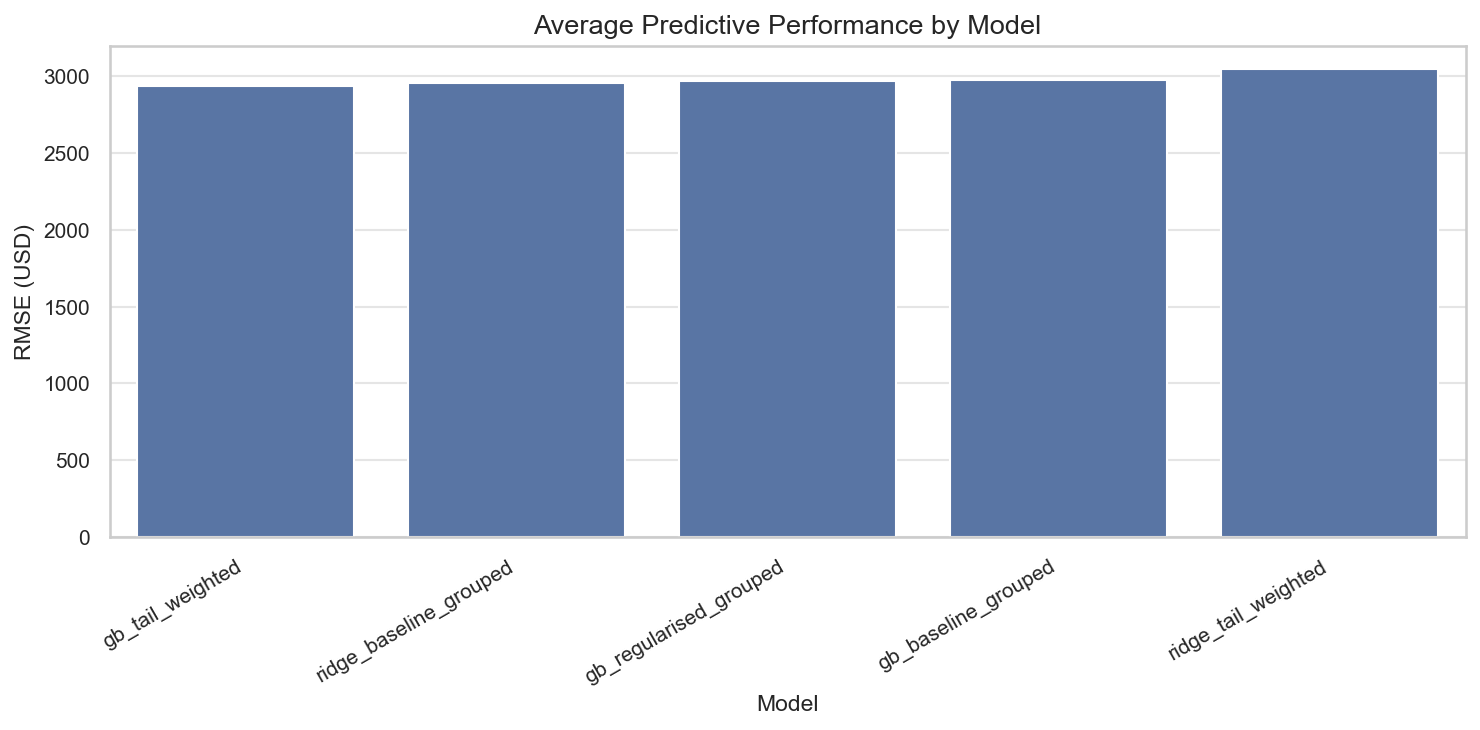

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\09_final_model_comparison_and_results_tables\Figures\fig_09_tail_threshold_underprediction.png


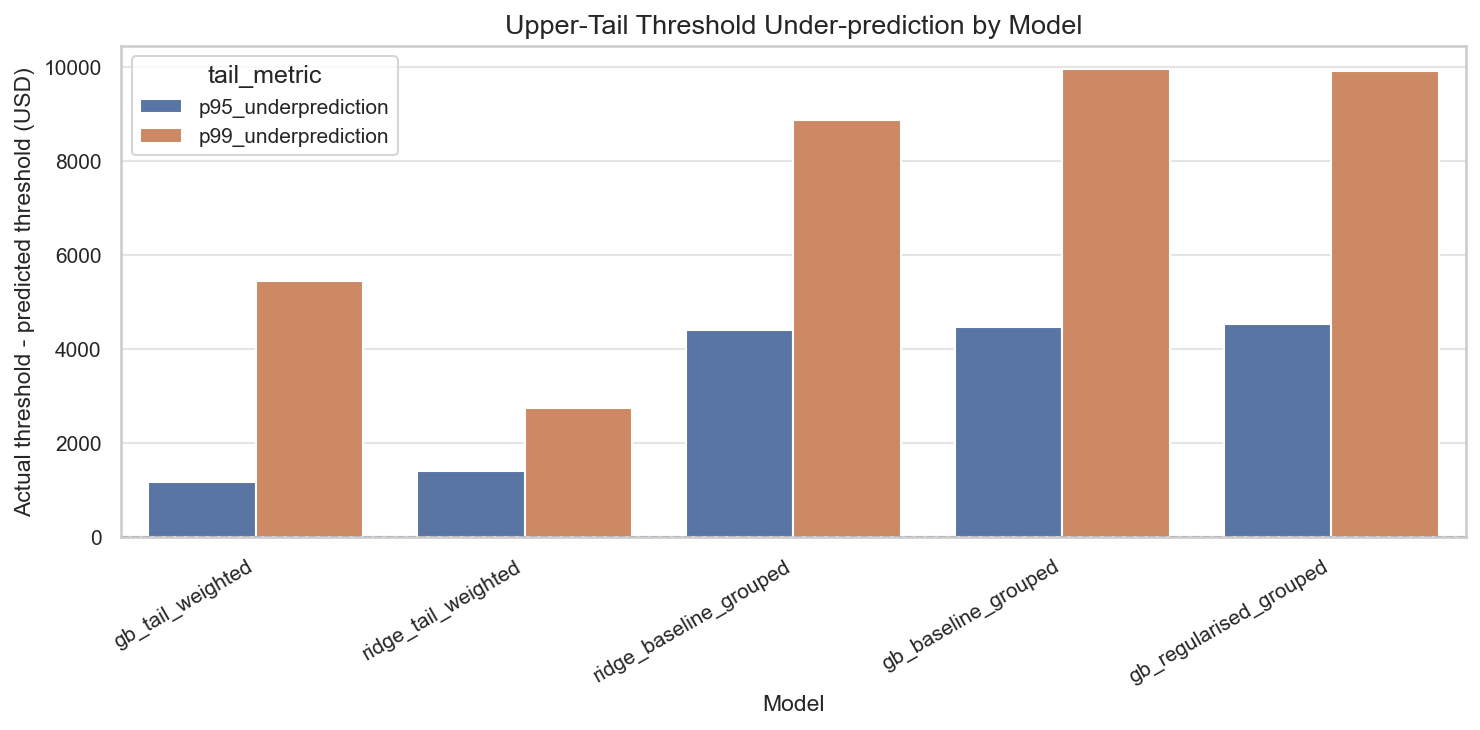

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\09_final_model_comparison_and_results_tables\Figures\fig_09_stress_total_cost_response.png


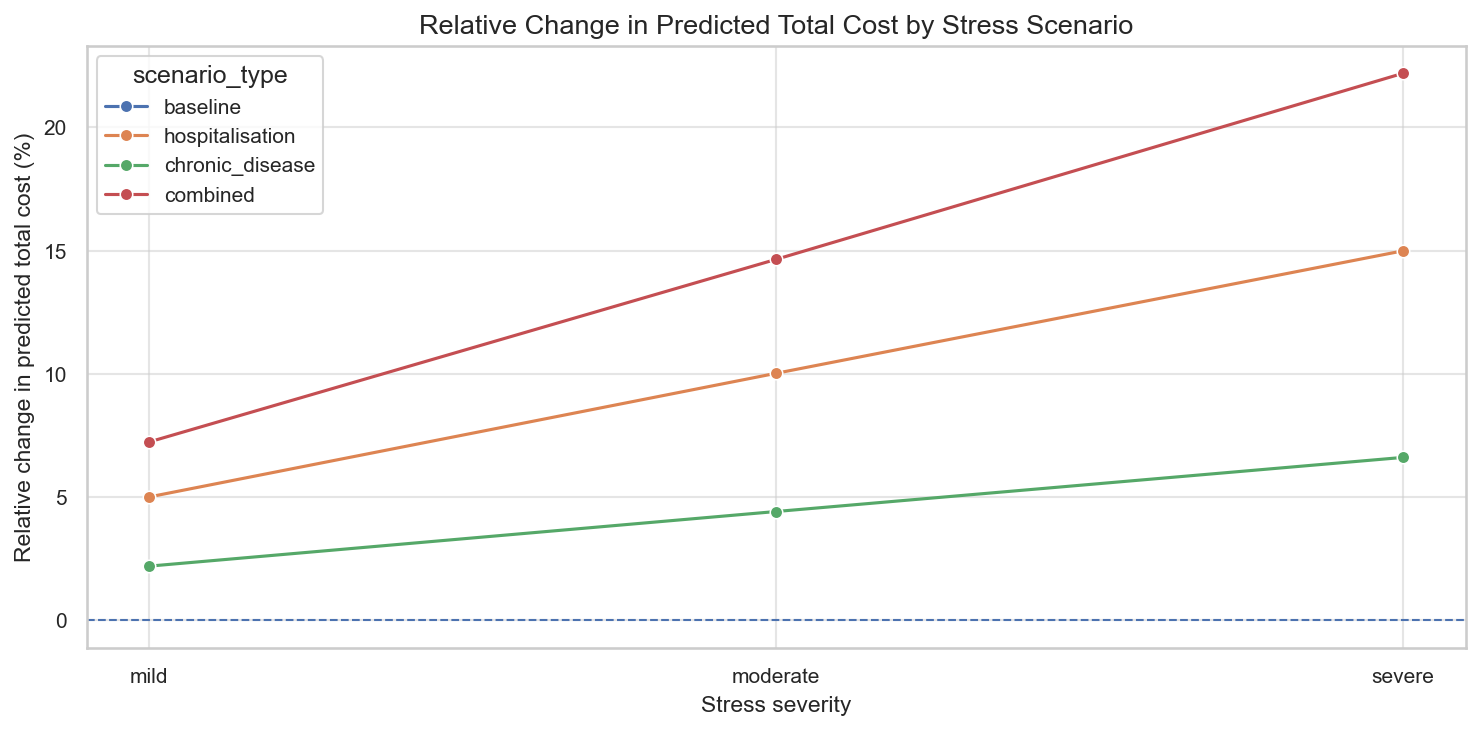

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\09_final_model_comparison_and_results_tables\Figures\fig_09_quantile_model_calibration.png


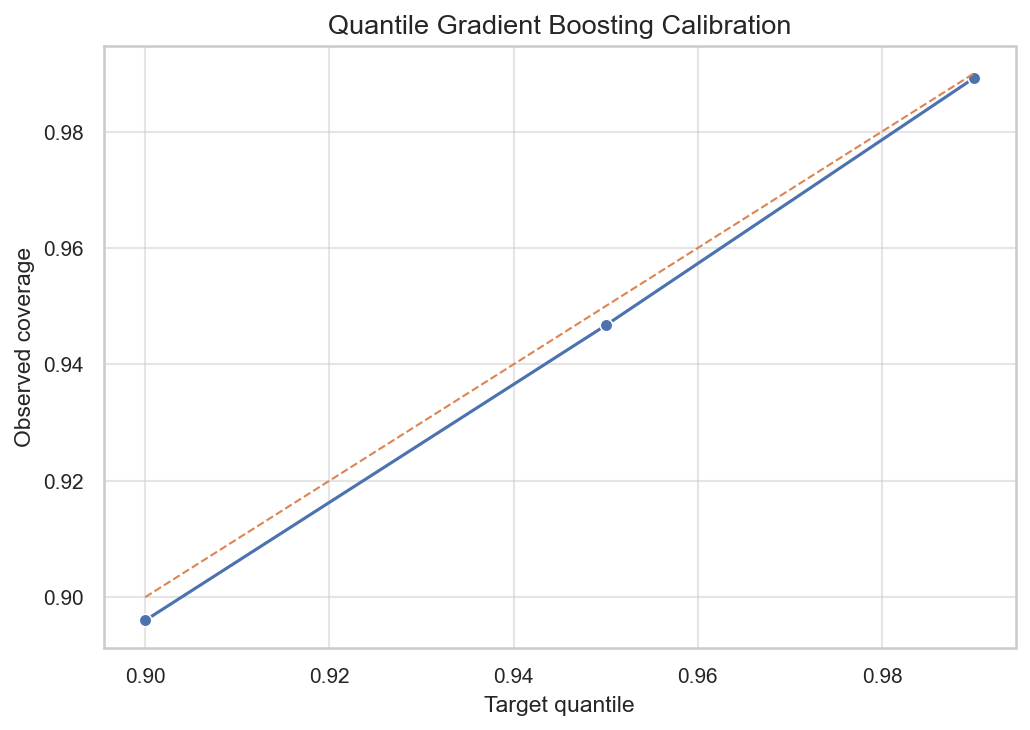

Saved figures:
C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\09_final_model_comparison_and_results_tables\Figures\fig_09_average_predictive_performance_rmse.png
C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\09_final_model_comparison_and_results_tables\Figures\fig_09_tail_threshold_underprediction.png
C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\09_final_model_comparison_and_results_tables\Figures\fig_09_stress_total_cost_response.png
C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\09_final_model_comparison_and_results_tables\Figures\fig_09_quantile_model_calibration.png


In [19]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

sns.barplot(
    data=final_average_model_performance_df,
    x="model_name",
    y="RMSE",
    ax=ax,
)

ax.set_title("Average Predictive Performance by Model")
ax.set_xlabel("Model")
ax.set_ylabel("RMSE (USD)")

plt.setp(
    ax.get_xticklabels(),
    rotation=30,
    ha="right",
)

fig.tight_layout()

average_performance_plot_path = save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_09_average_predictive_performance_rmse",
)

plt.show()

underprediction_plot_df = final_tail_risk_performance_df.melt(
    id_vars=["model_name"],
    value_vars=[
        "p95_underprediction",
        "p99_underprediction",
    ],
    var_name="tail_metric",
    value_name="underprediction",
)

fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

sns.barplot(
    data=underprediction_plot_df,
    x="model_name",
    y="underprediction",
    hue="tail_metric",
    ax=ax,
)

ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title("Upper-Tail Threshold Under-prediction by Model")
ax.set_xlabel("Model")
ax.set_ylabel("Actual threshold - predicted threshold (USD)")

plt.setp(
    ax.get_xticklabels(),
    rotation=30,
    ha="right",
)

fig.tight_layout()

tail_underprediction_plot_path = save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_09_tail_threshold_underprediction",
)

plt.show()

stress_plot_df = final_stress_aggregate_response_df[
    final_stress_aggregate_response_df["scenario_type"].astype(str) != "baseline"
    ].copy()

fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

sns.lineplot(
    data=stress_plot_df,
    x="severity",
    y="total_predicted_cost_pct_change_percent",
    hue="scenario_type",
    marker="o",
    ax=ax,
)

ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title("Relative Change in Predicted Total Cost by Stress Scenario")
ax.set_xlabel("Stress severity")
ax.set_ylabel("Relative change in predicted total cost (%)")

fig.tight_layout()

stress_cost_response_plot_path = save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_09_stress_total_cost_response",
)

plt.show()

fig, ax = plt.subplots(figsize=(7, 5), dpi=150)

sns.lineplot(
    data=final_quantile_model_diagnostics_df,
    x="target_quantile",
    y="observed_coverage",
    marker="o",
    ax=ax,
)

ax.plot(
    [0.90, 0.99],
    [0.90, 0.99],
    linestyle="--",
    linewidth=1,
)

ax.set_title("Quantile Gradient Boosting Calibration")
ax.set_xlabel("Target quantile")
ax.set_ylabel("Observed coverage")

fig.tight_layout()

quantile_calibration_plot_path = save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_09_quantile_model_calibration",
)

plt.show()

print("Saved figures:")
for path in [
    average_performance_plot_path,
    tail_underprediction_plot_path,
    stress_cost_response_plot_path,
    quantile_calibration_plot_path,
]:
    print(path)